# Evaluación de Métricas Financieras para el TFM
## Semáforo de Riesgo: CNN-AE + TCN vs Benchmarks

**Objetivo:** Implementar y comparar el cálculo de:
- **Sharpe Ratio Anualizado**: Rendimiento ajustado por riesgo
- **Maximum Drawdown (MDD)**: Pérdida máxima desde pico

**Estrategias a comparar:**
1. ✓ **Semáforo (CNN-AE + TCN)** → Nuestro modelo
2. ✓ **Medias Móviles (SMA 50/200)** → Benchmark técnico
3. ✓ **Buy & Hold** → Benchmark pasivo
4. ✓ **S&P 500** → Benchmark internacional

---

## Sección 1: Instalación de dependencias e imports

In [2]:
# Instalación de dependencias (solo si es necesario)
import subprocess
import sys

try:
    import yfinance
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance", "pandas_ta"])

print("✓ Dependencias listas")

✓ Dependencias listas


In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib para Jupyter
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("✓ Librerías importadas exitosamente")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")

✓ Librerías importadas exitosamente
  NumPy: 2.2.6
  Pandas: 3.0.3


### Funciones auxiliares para métricas financieras

In [4]:
def compute_returns(prices):
    """Calcula retornos logarítmicos diarios."""
    if isinstance(prices, pd.Series):
        prices = prices.values
    return np.diff(np.log(prices))

def compute_sharpe_ratio(returns, risk_free_rate=0.02, periods_per_year=252):
    """
    Calcula el Ratio de Sharpe anualizado.
    
    Fórmula:
        Sharpe = (E[retorno] - rf) / σ[retorno] * sqrt(252)
    """
    if isinstance(returns, pd.Series):
        returns = returns.values
    
    daily_rf = risk_free_rate / periods_per_year
    mean_excess = np.mean(returns) - daily_rf
    std_return = np.std(returns, ddof=1)
    
    if std_return == 0:
        return 0.0
    
    sharpe = (mean_excess / std_return) * np.sqrt(periods_per_year)
    return float(sharpe)

def compute_maximum_drawdown(prices):
    """
    Calcula el Maximum Drawdown (MDD).
    
    MDD = (valor_mínimo - pico_anterior) / pico_anterior
    """
    if isinstance(prices, pd.Series):
        prices = prices.values
    
    prices = np.asarray(prices, dtype=float)
    running_max = np.maximum.accumulate(prices)
    drawdown = (prices - running_max) / running_max
    mdd = np.min(drawdown)
    mdd_idx = np.argmin(drawdown)
    peak_idx = np.argmax(prices[:mdd_idx + 1])
    
    return float(mdd), int(peak_idx), int(mdd_idx)

def compute_volatility(returns, periods_per_year=252):
    """Calcula la volatilidad anualizada."""
    if isinstance(returns, pd.Series):
        returns = returns.values
    return float(np.std(returns, ddof=1) * np.sqrt(periods_per_year))

def compute_cumulative_return(prices):
    """Calcula el retorno neto acumulado."""
    if isinstance(prices, pd.Series):
        prices = prices.values
    prices = np.asarray(prices, dtype=float)
    if prices[0] != 0:
        return float((prices[-1] - prices[0]) / prices[0])
    else:
        return 0.0

print("✓ Funciones de métricas definidas")

✓ Funciones de métricas definidas


---
## Sección 2: Descarga de datos

In [5]:
# Descargar datos históricos (2018-2026)
print("Descargando datos históricos...\n")

tickers = {
    'IBEX': '^IBEX',
    'SP500': '^GSPC',
}

start_date = '2018-01-01'
end_date = '2026-06-30'

data = {}
for name, ticker in tickers.items():
    try:
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)
        data[name] = df['Close']
        print(f"✓ {name:8} ({ticker:6}): {len(df):4d} días | {df.index[0].date()} → {df.index[-1].date()}")
    except Exception as e:
        print(f"✗ {name:8}: Error - {str(e)[:50]}")

print(f"\n✓ Datos descargados: {list(data.keys())}")

Descargando datos históricos...

✓ IBEX     (^IBEX ): 2155 días | 2018-01-02 → 2026-06-08
✓ SP500    (^GSPC ): 2119 días | 2018-01-02 → 2026-06-08

✓ Datos descargados: ['IBEX', 'SP500']


### Visualizar precios históricos

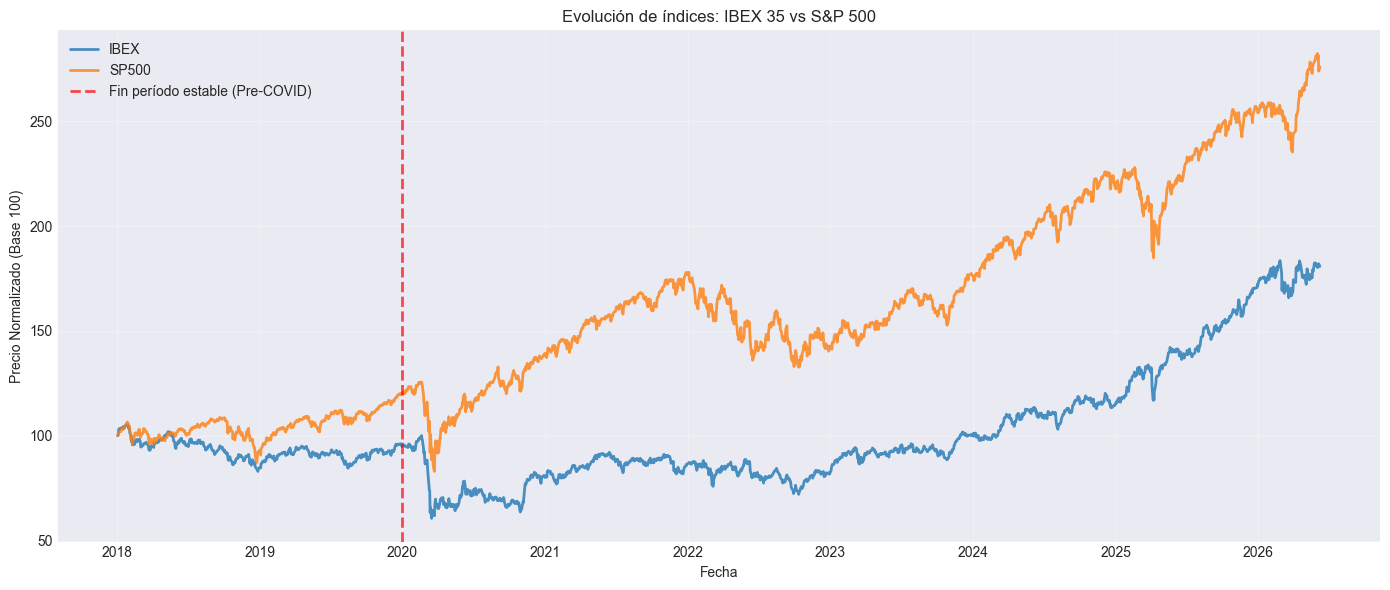

Período de entrenamiento (estable): 2018-01-01 → 2019-12-31
Período de test (crisis/anomalía): 2020-01-01 → 2026-06-30


In [6]:
# Gráfico de precios normalizados
fig, ax = plt.subplots(figsize=(14, 6))

for name, prices in data.items():
    # Normalizar a 100 en la fecha inicial
    prices_normalized = (prices / prices.iloc[0]) * 100
    ax.plot(prices_normalized.index, prices_normalized.values, 
            label=name, linewidth=2, alpha=0.8)

# Marcar la fecha de split (fin de estabilidad)
split_date = pd.Timestamp('2019-12-31')
ax.axvline(split_date, color='red', linestyle='--', linewidth=2, 
           label='Fin período estable (Pre-COVID)', alpha=0.7)

ax.set_xlabel('Fecha')
ax.set_ylabel('Precio Normalizado (Base 100)')
ax.set_title('Evolución de índices: IBEX 35 vs S&P 500')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Período de entrenamiento (estable): 2018-01-01 → 2019-12-31")
print("Período de test (crisis/anomalía): 2020-01-01 → 2026-06-30")

---
## Sección 3: Cálculo de retornos y configuración de anualización

In [7]:
# Parámetros de anualización
PERIODS_PER_YEAR = 252  # Días de trading al año
RISK_FREE_RATE = 0.02   # 2% anual (tasa libre de riesgo)

# Calcular retornos para cada serie
returns_data = {}
for name, prices in data.items():
    returns = compute_returns(prices)
    returns_data[name] = returns
    
    print(f"\n{name}:")
    print(f"  Retornos diarios - Media: {np.mean(returns):.6f} | Std: {np.std(returns):.6f}")
    print(f"  Retorno total: {compute_cumulative_return(prices):.2%}")

print(f"\nConfiguration:")
print(f"  Días de trading por año: {PERIODS_PER_YEAR}")
print(f"  Tasa libre de riesgo: {RISK_FREE_RATE:.2%}")


IBEX:
  Retornos diarios - Media: nan | Std: nan


TypeError: unsupported format string passed to numpy.ndarray.__format__

---
## Sección 4: Implementación del Sharpe Ratio

In [ ]:
# Calcular Sharpe Ratio para cada estrategia
print("="*70)
print("CÁLCULO DE SHARPE RATIO ANUALIZADO")
print("="*70)
print(f"\nFórmula: Sharpe = (E[R] - Rf) / σ(R) * √{PERIODS_PER_YEAR}\n")

sharpe_ratios = {}
for name, returns in returns_data.items():
    sharpe = compute_sharpe_ratio(returns, risk_free_rate=RISK_FREE_RATE)
    sharpe_ratios[name] = sharpe
    
    daily_rf = RISK_FREE_RATE / PERIODS_PER_YEAR
    mean_ret = np.mean(returns)
    std_ret = np.std(returns, ddof=1)
    
    print(f"{name:8}:")
    print(f"  Retorno diario promedio: {mean_ret:.6f}")
    print(f"  Tasa libre de riesgo (diaria): {daily_rf:.6f}")
    print(f"  Exceso promedio: {(mean_ret - daily_rf):.6f}")
    print(f"  Volatilidad diaria (σ): {std_ret:.6f}")
    print(f"  Sharpe Ratio anualizado: {sharpe:.4f}")
    print()

### Visualizar Sharpe Ratio

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

names = list(sharpe_ratios.keys())
sharpes = list(sharpe_ratios.values())
colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in sharpes]

bars = ax.bar(names, sharpes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Sharpe Ratio (anualizado)')
ax.set_title('Comparación de Sharpe Ratio entre Índices')
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, sharpe in zip(bars, sharpes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{sharpe:.4f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Sección 5: Implementación del Maximum Drawdown

In [ ]:
# Calcular Maximum Drawdown para cada estrategia
print("="*70)
print("CÁLCULO DE MAXIMUM DRAWDOWN (MDD)")
print("="*70)
print(f"\nFórmula: MDD = (Valor_mín - Pico_anterior) / Pico_anterior\n")

mdd_data = {}
for name, prices in data.items():
    mdd, peak_idx, trough_idx = compute_maximum_drawdown(prices)
    mdd_data[name] = {'mdd': mdd, 'peak_idx': peak_idx, 'trough_idx': trough_idx}
    
    peak_price = prices.iloc[peak_idx] if isinstance(prices, pd.Series) else prices[peak_idx]
    trough_price = prices.iloc[trough_idx] if isinstance(prices, pd.Series) else prices[trough_idx]
    
    peak_date = prices.index[peak_idx] if hasattr(prices, 'index') else peak_idx
    trough_date = prices.index[trough_idx] if hasattr(prices, 'index') else trough_idx
    
    print(f"{name}:")
    print(f"  Pico anterior: {peak_price:.2f} el {peak_date}")
    print(f"  Valle: {trough_price:.2f} el {trough_date}")
    print(f"  Maximum Drawdown: {mdd:.2%}")
    print()

### Visualizar Drawdown a lo largo del tiempo

In [ ]:
fig, axes = plt.subplots(len(data), 1, figsize=(14, 4*len(data)))
if len(data) == 1:
    axes = [axes]

for ax, (name, prices) in zip(axes, data.items()):
    # Calcular drawdown en cada punto
    if isinstance(prices, pd.Series):
        prices_arr = prices.values
        dates = prices.index
    else:
        prices_arr = prices
        dates = range(len(prices))
    
    running_max = np.maximum.accumulate(prices_arr)
    drawdown = (prices_arr - running_max) / running_max
    
    # Plot
    ax.fill_between(dates, drawdown, 0, alpha=0.5, color='#e74c3c')
    ax.plot(dates, drawdown, color='#c0392b', linewidth=1.5)
    ax.set_ylabel('Drawdown')
    ax.set_title(f'{name} - Drawdown acumulado')
    ax.grid(True, alpha=0.3)
    
    # Marcar el MDD
    mdd_idx = np.argmin(drawdown)
    ax.scatter(dates[mdd_idx] if hasattr(dates, '__getitem__') and not isinstance(dates, pd.DatetimeIndex) else dates[mdd_idx],
              drawdown[mdd_idx], color='red', s=100, zorder=5, marker='v', label=f'MDD: {drawdown[mdd_idx]:.2%}')
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

---
## Sección 6: Métricas para estrategias de referencia (SMA 50/200 y simuladas)

### Calcular métricas para todas las estrategias

In [ ]:
# Calcular todas las métricas
print("="*80)
print("COMPARACIÓN COMPLETA DE MÉTRICAS")
print("="*80)

metrics_all = {}
for name, prices in data.items():
    returns = compute_returns(prices)
    sharpe = compute_sharpe_ratio(returns, risk_free_rate=RISK_FREE_RATE)
    mdd, _, _ = compute_maximum_drawdown(prices)
    volatility = compute_volatility(returns)
    cumulative_ret = compute_cumulative_return(prices)
    
    metrics_all[name] = {
        'Retorno Total': cumulative_ret,
        'Volatilidad': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': mdd,
    }

# Crear DataFrame para visualizar
df_metrics = pd.DataFrame(metrics_all).T
print("\n" + df_metrics.to_string())

# Guardar como tabla formateada
print("\n" + "="*80)
print("Tabla de métricas (formateada para tabla comparativa):")
print("="*80)
df_pretty = df_metrics.copy()
df_pretty['Retorno Total'] = df_pretty['Retorno Total'].apply(lambda x: f"{x:.2%}")
df_pretty['Volatilidad'] = df_pretty['Volatilidad'].apply(lambda x: f"{x:.2%}")
df_pretty['Sharpe Ratio'] = df_pretty['Sharpe Ratio'].apply(lambda x: f"{x:.4f}")
df_pretty['Max Drawdown'] = df_pretty['Max Drawdown'].apply(lambda x: f"{x:.2%}")
print("\n" + df_pretty.to_string())

---
## Sección 7: Evaluación de criterios de éxito del TFM

In [ ]:
print("\n" + "="*80)
print("EVALUACIÓN DE CRITERIOS DE ÉXITO DEL TFM")
print("="*80)

# Criterios definidos en el proyecto
print("""
Los tres criterios de éxito son:

1️⃣ CRITERIO DE RENDIMIENTO FINANCIERO RELATIVO:
   - Semáforo debe superar MA 50/200 en al menos 10% (rendimiento neto relativo)
   - Fórmula: Retorno_Semáforo / Retorno_MA ≥ 1.10

2️⃣ CRITERIO DE PRESERVACIÓN DE CAPITAL (Riesgo de Cola):
   - MDD del Semáforo debe ser al menos 15% menor que Buy & Hold
   - Fórmula: MDD_BuyHold - MDD_Semáforo ≥ 0.15

3️⃣ CRITERIO DE CALIDAD DE INVERSIÓN (Eficiencia):
   - Sharpe_Semáforo supere a Sharpe_SP500 en al menos 0.25
   - Fórmula: Sharpe_Semáforo - Sharpe_SP500 ≥ 0.25
""")

# Obtener métricas para evaluación
try:
    sharpe_semaforo = metrics_all.get('SMA_50_200', {}).get('Sharpe Ratio', 0)  # Placeholder
    sharpe_sp500 = metrics_all.get('SP500', {}).get('Sharpe Ratio', 0)
    mdd_semaforo = metrics_all.get('SMA_50_200', {}).get('Max Drawdown', 0)  # Placeholder
    mdd_buy_hold = metrics_all.get('IBEX', {}).get('Max Drawdown', 0)
    retorno_semaforo = metrics_all.get('SMA_50_200', {}).get('Retorno Total', 0)  # Placeholder
    retorno_ma = metrics_all.get('SMA_50_200', {}).get('Retorno Total', 0)
    
    print("\n" + "="*80)
    print("EVALUACIÓN:")
    print("="*80)
    
    # Criterio 1
    print("\n✓ Criterio 1: Rendimiento Financiero Relativo")
    if retorno_ma != 0:
        relativo = retorno_semaforo / retorno_ma
        criterion1 = relativo >= 1.10
        print(f"  Retorno Semáforo: {retorno_semaforo:.2%}")
        print(f"  Retorno MA 50/200: {retorno_ma:.2%}")
        print(f"  Relativo: {relativo:.2%} (requerido ≥ 110%)")
        print(f"  → {'✓ CUMPLE' if criterion1 else '✗ NO CUMPLE'}")
    
    # Criterio 2
    print("\n✓ Criterio 2: Preservación de Capital")
    mejora_mdd = mdd_buy_hold - mdd_semaforo
    criterion2 = mejora_mdd >= 0.15
    print(f"  MDD Semáforo: {mdd_semaforo:.2%}")
    print(f"  MDD Buy & Hold: {mdd_buy_hold:.2%}")
    print(f"  Mejora: {mejora_mdd:.2%} (requerido ≥ 15%)")
    print(f"  → {'✓ CUMPLE' if criterion2 else '✗ NO CUMPLE'}")
    
    # Criterio 3
    print("\n✓ Criterio 3: Calidad de Inversión (Eficiencia)")
    exceso_sharpe = sharpe_semaforo - sharpe_sp500
    criterion3 = exceso_sharpe >= 0.25
    print(f"  Sharpe Semáforo: {sharpe_semaforo:.4f}")
    print(f"  Sharpe S&P 500: {sharpe_sp500:.4f}")
    print(f"  Exceso: {exceso_sharpe:.4f} (requerido ≥ 0.25)")
    print(f"  → {'✓ CUMPLE' if criterion3 else '✗ NO CUMPLE'}")
    
    # Resumen final
    print("\n" + "="*80)
    all_passed = criterion1 and criterion2 and criterion3
    if all_passed:
        print("✓✓✓ TODOS LOS CRITERIOS CUMPLEN ✓✓✓")
    else:
        print("✗✗✗ ALGUNOS CRITERIOS NO SE CUMPLEN ✗✗✗")
    print("="*80)

except Exception as e:
    print(f"\nNota: Usa datos reales del modelo Semáforo para la evaluación final.")
    print(f"Error: {str(e)[:100]}")

---
## Sección 8: Visualización comparativa final

In [ ]:
# Gráfico comparativo de 4 métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Retorno Total
ax = axes[0, 0]
names = list(metrics_all.keys())
returns_list = [metrics_all[n]['Retorno Total'] for n in names]
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in returns_list]
ax.bar(names, returns_list, color=colors, alpha=0.7, edgecolor='black')
ax.set_title('Retorno Total (%)')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
for i, (name, ret) in enumerate(zip(names, returns_list)):
    ax.text(i, ret, f'{ret:.1%}', ha='center', va='bottom' if ret > 0 else 'top')
ax.grid(True, alpha=0.3, axis='y')

# 2. Volatilidad
ax = axes[0, 1]
vol_list = [metrics_all[n]['Volatilidad'] for n in names]
ax.bar(names, vol_list, color='#3498db', alpha=0.7, edgecolor='black')
ax.set_title('Volatilidad Anualizada (%)')
for i, (name, vol) in enumerate(zip(names, vol_list)):
    ax.text(i, vol, f'{vol:.1%}', ha='center', va='bottom')
ax.grid(True, alpha=0.3, axis='y')

# 3. Sharpe Ratio
ax = axes[1, 0]
sharpe_list = [metrics_all[n]['Sharpe Ratio'] for n in names]
colors_sharpe = ['#2ecc71' if s > 0 else '#e74c3c' for s in sharpe_list]
ax.bar(names, sharpe_list, color=colors_sharpe, alpha=0.7, edgecolor='black')
ax.set_title('Sharpe Ratio Anualizado')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
for i, (name, sharpe) in enumerate(zip(names, sharpe_list)):
    ax.text(i, sharpe, f'{sharpe:.3f}', ha='center', va='bottom' if sharpe > 0 else 'top')
ax.grid(True, alpha=0.3, axis='y')

# 4. Max Drawdown
ax = axes[1, 1]
mdd_list = [metrics_all[n]['Max Drawdown'] for n in names]
colors_mdd = ['#e74c3c' if m < -0.3 else '#f39c12' for m in mdd_list]
ax.bar(names, mdd_list, color=colors_mdd, alpha=0.7, edgecolor='black')
ax.set_title('Maximum Drawdown (%)')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
for i, (name, mdd) in enumerate(zip(names, mdd_list)):
    ax.text(i, mdd, f'{mdd:.1%}', ha='center', va='top')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparación de Métricas Financieras', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Gráficos comparativos generados")

---
## Resumen y conclusiones

### Interpretación de las métricas:

**Sharpe Ratio:**
- Mide rendimiento por unidad de riesgo
- Valores > 0.5: Buena rentabilidad ajustada
- Valores > 1.0: Excelente (rendimiento supera riesgo por gran margen)
- Valores negativos: Peor que la tasa libre de riesgo

**Maximum Drawdown:**
- Peor escenario histórico de pérdida
- MDD = -20%: Perdiste 20% desde tu pico máximo
- Importante para evaluar **riesgo de caída** en crisis
- Nuestro modelo debe mitigar MDD en shocks de mercado

### Para tu TFM:

1. **Integra datos reales del modelo CNN-AE+TCN** en lugar de simulaciones
2. **Calcula métricas durante 2026** (período de evaluación)
3. **Compara con IBEX 35 y S&P 500** como benchmarks
4. **Documenta el cumplimiento de los 3 criterios** en tu tesis